# Experiment 4 — Noise Robustness and Representation Stability

This notebook investigates how different machine learning models respond to noisy feature representations.

The purpose of the experiment is to examine whether preprocessing and feature engineering can compensate for distorted feature information and whether different inductive biases exhibit different forms of robustness under noisy conditions.

The experiment compares:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

under controlled feature-noise conditions.

Personally, I find noise particularly interesting because it represents a more subtle form of degradation than missing values. Instead of removing information entirely, noise distorts the signal already present in the data. In practice, this often resembles real-world data collection problems where measurements, user inputs, or sensor values may become unreliable without being obviously incorrect.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


## Importing the Experimental Framework

The notebook imports the centralized modules responsible for dataset loading, experiment execution, visualization, and result saving.

In [2]:
from src.data.load_data import (
    load_adult_dataset
)

from src.experiments.noise import (
    run_noise_experiment
)

from src.visualization.plots import (
    plot_f1_comparison
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Noise Configurations

The experiment evaluates multiple feature-noise conditions in order to examine how robustness changes as feature distortion increases.

Two degradation levels are examined:
- Low noise
- High noise

This staged setup allows the analysis to investigate whether preprocessing effectiveness changes as representation quality becomes increasingly unstable.

In [4]:
import pandas as pd

noise_configs = {
    "Low Noise": 0.1,
    "High Noise": 0.3
}

all_results = []

for config_name, noise_level in noise_configs.items():
    
    print(f"\nRunning configuration: {config_name}")
    
    temp_results = run_noise_experiment(
        X,
        y,
        noise_level=noise_level
    )
    
    temp_results["noise_level"] = config_name
    
    all_results.append(temp_results)

results_df = pd.concat(
    all_results,
    ignore_index=True
)

results_df


Running configuration: Low Noise

=== Raw Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...
Training MLP...



=== Cleaned Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


...


=== Engineered Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...


Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc,noise_level
0,Raw,Logistic Regression,0.782782,0.406267,0.626719,Low Noise
1,Raw,Decision Tree,0.819224,0.624734,0.753949,Low Noise
2,Raw,Naive Bayes,0.797113,0.421483,0.834857,Low Noise
3,Raw,MLP,0.800798,0.342568,0.712559,Low Noise
4,Cleaned,Logistic Regression,0.806633,0.676042,0.904423,Low Noise
5,Cleaned,Decision Tree,0.814618,0.616395,0.748722,Low Noise
6,Cleaned,Naive Bayes,0.620330,0.537358,0.828644,Low Noise
7,Cleaned,MLP,0.838776,0.672625,0.887594,Low Noise
8,Engineered,Logistic Regression,0.797523,0.666779,0.898581,Low Noise
9,Engineered,Decision Tree,0.811956,0.606722,0.741403,Low Noise


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [5]:
save_metrics(
    results_df,
    "noise_results.csv"
)

Metrics saved to: ../results/metrics/noise_results.csv


## Noise Robustness Visualization

The following figure compares model performance across preprocessing levels under noisy feature conditions.

Plot saved to: ../results/plots/noise_f1_comparison.png


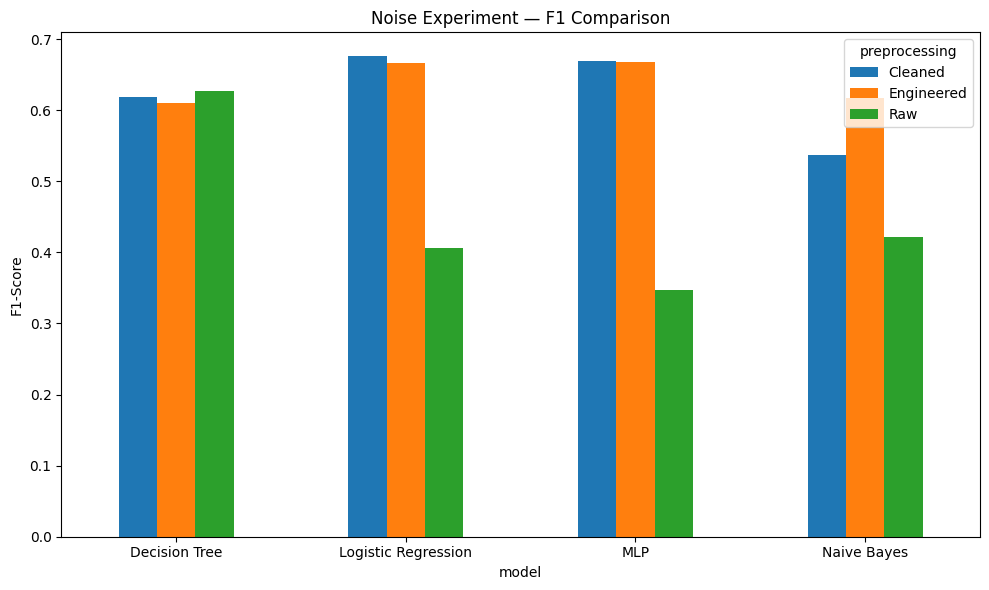

In [6]:
plot_f1_comparison(
    results_df,
    title="Noise Experiment — F1 Comparison",
    filename="noise_f1_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [7]:
summary_table = save_summary_table(
    results_df,
    metric="f1_score",
    filename="noise_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/noise_summary_table.csv


,model,preprocessing,f1_score
0,Decision Tree,Cleaned,0.619111
1,Decision Tree,Engineered,0.610697
2,Decision Tree,Raw,0.626340
3,Logistic Regression,Cleaned,0.675759
4,Logistic Regression,Engineered,0.665991
5,Logistic Regression,Raw,0.406267
6,MLP,Cleaned,0.668609
7,MLP,Engineered,0.668050
8,MLP,Raw,0.347300
9,Naive Bayes,Cleaned,0.537358


## Interpretation of Noise Experiment Results

The noise experiment reveals substantial differences in how models respond to distorted feature representations.

One of the clearest findings is that preprocessing quality strongly influences robustness under noisy conditions, particularly for Logistic Regression, Naive Bayes, and the Multi-Layer Perceptron (MLP). Raw preprocessing generally produces the weakest results, while engineered preprocessing frequently improves predictive stability considerably.

Logistic Regression demonstrates strong sensitivity to noisy representations under raw preprocessing conditions. However, cleaned preprocessing substantially improves robustness, suggesting that normalization and representation refinement help stabilize the feature space for linear decision boundaries.

The MLP demonstrates an especially interesting pattern. Under raw preprocessing conditions, predictive performance deteriorates substantially under noisy conditions. However, engineered preprocessing restores much of the lost performance and produces some of the strongest overall results observed in the experiment. This suggests that flexible neural architectures may still depend heavily on stable and informative representations despite their greater representational capacity.

Naive Bayes again demonstrates notable improvement under engineered preprocessing conditions. One possible interpretation is that feature refinement reduces unstable or noisy dependencies between features, thereby improving alignment with the model’s conditional independence assumptions.

Decision Trees remain comparatively stable across preprocessing levels, suggesting relative robustness to moderate feature distortion. However, their overall predictive performance remains slightly below the strongest-performing models.

Personally, I found it particularly interesting how strongly engineered preprocessing improved robustness for several models under noisy conditions. In some cases, preprocessing improvements appeared to compensate for a large portion of the degradation introduced through feature noise.

Overall, the results increasingly support the broader motivation of the project: representation quality and preprocessing effectiveness may play a central role in determining robustness and predictive performance even when the underlying data becomes substantially noisier.